In [2]:
# Insurance Claims & Portfolio Risk Analytics

## Project 01 - Python + Tableau

### Objective
Analyze the insurance portfolio, understand claim frequency and severity patterns,
prepare a clean analysis-ready dataset, and build an executive Tableau dashboard.

SyntaxError: invalid syntax (2647818808.py, line 6)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# load data

In [5]:
freq_raw = pd.read_csv(r"D:\projects\studybuild-project 3-insurance\csv\freMTPL2freq.csv")
sev_raw = pd.read_csv(r"D:\projects\studybuild-project 3-insurance\csv\freMTPL2sev.csv")

In [6]:
freq = freq_raw.copy()
sev = sev_raw.copy()

In [7]:
print("Frequency dataset shape:", freq.shape)
print("Severity dataset shape:", sev.shape)

Frequency dataset shape: (677991, 12)
Severity dataset shape: (26444, 2)


In [8]:
# data understanding

In [9]:
freq.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,0,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,0,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,0,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,0,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,0,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


In [10]:
sev.head()

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


In [11]:
freq.columns.tolist()


['IDpol',
 'ClaimNb',
 'Exposure',
 'VehPower',
 'VehAge',
 'DrivAge',
 'BonusMalus',
 'VehBrand',
 'VehGas',
 'Area',
 'Density',
 'Region']

In [12]:
sev.columns.tolist()

['IDpol', 'ClaimAmount']

In [13]:
freq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677991 entries, 0 to 677990
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       677991 non-null  float64
 1   ClaimNb     677991 non-null  int64  
 2   Exposure    677991 non-null  float64
 3   VehPower    677991 non-null  int64  
 4   VehAge      677991 non-null  int64  
 5   DrivAge     677991 non-null  int64  
 6   BonusMalus  677991 non-null  int64  
 7   VehBrand    677991 non-null  object 
 8   VehGas      677991 non-null  object 
 9   Area        677991 non-null  object 
 10  Density     677991 non-null  int64  
 11  Region      677991 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB


In [14]:
sev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26444 entries, 0 to 26443
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26444 non-null  int64  
 1   ClaimAmount  26444 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 413.3 KB


In [15]:
freq.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,6.779910e+05,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000
mean,2.621886e+06,0.039003,0.528743,6.454649,7.044244,45.499092,59.761559,1792.406856
std,1.641776e+06,0.207169,0.364441,2.050914,5.666226,14.137449,15.636713,3958.574057
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157964e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272157e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046271e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


In [16]:
sev.describe()

,IDpol,ClaimAmount
count,2.644400e+04,2.644400e+04
mean,2.280004e+06,2.265513e+03
std,1.583004e+06,2.937103e+04
min,1.390000e+02,1.000000e+00
25%,1.086381e+06,6.859925e+02
50%,2.133756e+06,1.172000e+03
75%,3.183953e+06,1.212385e+03
max,6.113971e+06,4.075401e+06


In [17]:
categorical_cols = freq.select_dtypes(include="object").columns

categorical_cols

Index(['VehBrand', 'VehGas', 'Area', 'Region'], dtype='object')

In [18]:
freq[categorical_cols].nunique()

VehBrand    11
VehGas       2
Area         6
Region      22
dtype: int64

In [19]:
for col in categorical_cols:
    print(f"\n {col}:")
    print(freq[col].nunique())


 VehBrand:
11

 VehGas:
2

 Area:
6

 Region:
22


In [20]:
for col in categorical_cols:
    print(f"\n {col}:")
    print(freq[col].value_counts())


 VehBrand:
VehBrand
B12    166022
B1     162730
B2     159854
B3      53393
B5      34752
B6      28545
B4      25179
B10     17707
B11     13585
B13     12177
B14      4047
Name: count, dtype: int64

 VehGas:
VehGas
Regular    345863
Diesel     332128
Name: count, dtype: int64

 Area:
Area
C    191874
D    151592
E    137163
A    103952
B     75457
F     17953
Name: count, dtype: int64

 Region:
Region
Centre                         160595
Rhone-Alpes                     84748
Provence-Alpes-Cotes-D'Azur     79315
Ile-de-France                   69789
Bretagne                        42120
Pays-de-la-Loire                38747
Languedoc-Roussillon            35805
Aquitaine                       31329
Nord-Pas-de-Calais              27284
Poitou-Charentes                19046
Midi-Pyrenees                   17141
Lorraine                        12990
Basse-Normandie                 10892
Bourgogne                       10491
Haute-Normandie                  8784
Picardie              

In [21]:
print("Rows:", len(freq))
print("Unique policy IDs:", freq["IDpol"].nunique())

Rows: 677991
Unique policy IDs: 677991


In [22]:
freq["IDpol"].duplicated().sum()

np.int64(0)

In [23]:
print("Rows:", len(sev))
print("Unique policy IDs:", sev["IDpol"].nunique())

Rows: 26444
Unique policy IDs: 24944


In [24]:
sev["IDpol"].duplicated().sum()

np.int64(1500)

In [25]:
#data quality check

In [26]:
freq_missing = pd.DataFrame({
    "Missing_Count": freq.isnull().sum(),
    "Missing_Percentage": freq.isnull().mean() * 100
})

freq_missing

,Missing_Count,Missing_Percentage
IDpol,0,0.0
ClaimNb,0,0.0
Exposure,0,0.0
VehPower,0,0.0
VehAge,0,0.0
DrivAge,0,0.0
BonusMalus,0,0.0
VehBrand,0,0.0
VehGas,0,0.0
Area,0,0.0


In [27]:
sev_missing = pd.DataFrame({
    "Missing_Count": sev.isnull().sum(),
    "Missing_Percentage": sev.isnull().mean() * 100
})

sev_missing

,Missing_Count,Missing_Percentage
IDpol,0,0.0
ClaimAmount,0,0.0


In [28]:
freq.duplicated().sum()

np.int64(0)

In [29]:
sev.duplicated().sum()

np.int64(235)

In [30]:
print("Rows:", len(freq))
print("Unique IDpol:", freq["IDpol"].nunique())
print("Duplicated IDpol:", freq["IDpol"].duplicated().sum())

Rows: 677991
Unique IDpol: 677991
Duplicated IDpol: 0


In [31]:
print("Rows:", len(sev))
print("Unique IDpol:", sev["IDpol"].nunique())
print("Repeated IDpol rows:", sev["IDpol"].duplicated().sum())

Rows: 26444
Unique IDpol: 24944
Repeated IDpol rows: 1500


In [32]:
sev["IDpol"].value_counts().value_counts().sort_index()

count
1     23571
2      1298
3        62
4         5
5         2
6         1
8         1
9         1
11        2
16        1
Name: count, dtype: int64

In [33]:
#Frequency: IDpol is unique and consistent with policy-level grain.
#Severity: IDpol is not unique, which is expected because a policy may have multiple claim records.

In [34]:
check_cols = [
    "ClaimNb",
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "Density"
]

freq[check_cols].describe()

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000
mean,0.039003,0.528743,6.454649,7.044244,45.499092,59.761559,1792.406856
std,0.207169,0.364441,2.050914,5.666226,14.137449,15.636713,3958.574057
min,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


In [35]:
freq["ClaimNb"].value_counts().sort_index()

ClaimNb
0     653047
1      23571
2       1298
3         62
4          5
5          2
6          1
8          1
9          1
11         2
16         1
Name: count, dtype: int64

In [36]:
freq[freq["Exposure"] > 1]["Exposure"].describe()

count    1224.000000
mean        1.113840
std         0.159296
min         1.010000
25%         1.020000
50%         1.040000
75%         1.150000
max         2.010000
Name: Exposure, dtype: float64

In [37]:
(freq["Exposure"] > 1).sum()

np.int64(1224)

In [38]:
freq[freq["VehAge"]>=50]["VehAge"].value_counts().sort_index()

VehAge
50      8
51      4
52      6
53      2
54      2
55      1
59      2
60      1
62      1
63      1
64      1
65      2
66      2
68      2
69      4
70      3
71      1
76      1
78      1
79      1
80      3
81      3
82      1
83      2
84      1
85      1
99     23
100    25
Name: count, dtype: int64

In [39]:
freq[freq["DrivAge"]>=90]["DrivAge"].value_counts().sort_index()

DrivAge
90     167
91     121
92      66
93      55
94      32
95      24
96      15
97      10
98       5
99      70
100      3
Name: count, dtype: int64

In [40]:
freq[freq["BonusMalus"]>=150]["BonusMalus"].value_counts().sort_index()

BonusMalus
151      1
156    139
158      4
162      2
163      1
165     11
166      2
173      7
174      2
175      3
176      3
177      2
183      6
185      5
187      3
190      3
195      6
196      3
198      2
208      1
218      1
228      1
230      1
Name: count, dtype: int64

In [41]:
freq["Density"].quantile([0.90, 0.95, 0.99, 0.999])

0.900     4128.0
0.950     7313.0
0.990    27000.0
0.999    27000.0
Name: Density, dtype: float64

In [42]:
sev["ClaimAmount"].describe()

count    2.644400e+04
mean     2.265513e+03
std      2.937103e+04
min      1.000000e+00
25%      6.859925e+02
50%      1.172000e+03
75%      1.212385e+03
max      4.075401e+06
Name: ClaimAmount, dtype: float64

In [43]:
sev["ClaimAmount"].quantile([0.90, 0.95, 0.99, 0.999])

0.900      2767.60400
0.950      4765.09350
0.990     16451.22400
0.999    152223.24082
Name: ClaimAmount, dtype: float64

In [44]:
sev.nlargest(10, "ClaimAmount")

,IDpol,ClaimAmount
9756,1120377,4075400.56
15768,110846,1403057.40
11637,2141337,1301172.60
17992,3122016,774411.50
2869,2008127,390742.27
3307,3025890,369131.88
9999,1117644,307096.42
5521,158309,301635.49
18627,3075820,287423.00
18295,3150210,281897.49


In [45]:
### Data Cleaning & Quality Checks
#- No missing values were found in either dataset.
#- `IDpol` is unique in the frequency dataset and repeated in the severity dataset, which is expected because one policy may have multiple claims.
#- Most policies have zero claims, while high claim counts are very rare.
#- Extreme values were observed in variables such as `Exposure`, `VehAge`, `DrivAge`, `BonusMalus`, `Density`, and especially `ClaimAmount`.
#- `ClaimAmount` is strongly right-skewed, with a small number of very large claims.
#- No extreme values were removed at this stage. They were retained for further investigation during EDA, Pareto analysis, and extreme-claim review.

In [46]:
##  Severity Aggregation

#The severity dataset is claim-level, while the frequency dataset is policy-level.
#Claim amounts are therefore aggregated by `IDpol` before merging the datasets.

In [47]:
sev_policy = (
    sev.groupby("IDpol" , as_index = False)
        .agg(
            total_claim_cost = ("ClaimAmount" , "sum"),
            observed_claim_rows = ("ClaimAmount" , "size"),
            max_claim_amount = ("ClaimAmount" , "max")
        )
)

In [48]:
sev_policy.head()

,IDpol,total_claim_cost,observed_claim_rows,max_claim_amount
0,139,303.00,1,303.00
1,190,1981.84,1,1981.84
2,414,1456.55,1,1456.55
3,424,10834.00,2,9844.36
4,463,3986.67,1,3986.67


In [49]:
print("Original severity rows:", len(sev))
print("Aggregated policy rows:", len(sev_policy))

Original severity rows: 26444
Aggregated policy rows: 24944


In [50]:
print("Original claim rows:", len(sev))
print("Aggregated claim rows:", sev_policy["observed_claim_rows"].sum())

Original claim rows: 26444
Aggregated claim rows: 26444


In [51]:
print("Original total claim cost:", sev["ClaimAmount"].sum())
print("Aggregated total claim cost:", sev_policy["total_claim_cost"].sum())

Original total claim cost: 59909216.5
Aggregated total claim cost: 59909216.50000001


In [52]:
sev_policy.nlargest(10, "observed_claim_rows")

,IDpol,total_claim_cost,observed_claim_rows,max_claim_amount
14312,2241683,35529.37,16,10000.00
19464,3253234,25684.42,11,8000.00
19473,3254353,17587.78,11,4802.27
14328,2248174,18354.66,9,5000.00
14301,2239279,24825.77,8,8596.96
14094,2216294,9653.60,6,5046.63
2396,93954,6918.10,5,2405.62
14888,2277762,28672.00,5,23000.00
1146,54009,4882.44,4,2187.66
15244,3016883,4346.87,4,3376.22


In [53]:
sev_policy.nlargest(10, "total_claim_cost")

,IDpol,total_claim_cost,observed_claim_rows,max_claim_amount
7487,1120377,4075400.56,1,4075400.56
2842,110846,1404185.52,2,1403057.40
12729,2141337,1301172.60,1,1301172.60
17083,3122016,774411.50,1,774411.50
9764,2008127,399213.66,3,390742.27
15353,3025890,382955.14,2,369131.88
7357,1117644,307096.42,1,307096.42
3800,158309,301635.49,1,301635.49
16181,3075820,287423.00,1,287423.00
17788,3150210,281897.49,1,281897.49


In [54]:
### Severity Aggregation

#- Claim-level severity records were aggregated to the policy level using `IDpol`.
#- `total_claim_cost`, `observed_claim_rows`, and `max_claim_amount` were created for each policy.
#- The aggregation preserved both the total number of claim records and the total claim cost.
#- The aggregated severity table is now ready to be merged with the policy-level frequency dataset.

In [55]:
# Merge & Validation

In [56]:
freq["IDpol"] = freq["IDpol"].astype("int64")
sev_policy["IDpol"] = sev_policy["IDpol"].astype("int64")

In [57]:
freq["IDpol"].dtype

dtype('int64')

In [58]:
sev_policy["IDpol"].dtype

dtype('int64')

In [59]:
portfolio = freq.merge(
    sev_policy,
    on = "IDpol",
    how = "left",
    validate = "one_to_one",
    indicator = True
)

In [60]:
portfolio.shape

(677991, 16)

In [61]:
print("Frequency rows:", len(freq))
print("Merged rows:", len(portfolio))

Frequency rows: 677991
Merged rows: 677991


In [62]:
portfolio["_merge"].value_counts()   

_merge
left_only     653047
both           24944
right_only         0
Name: count, dtype: int64

In [63]:
print("Exposure before merge:", freq["Exposure"].sum())
print("Exposure after merge:", portfolio["Exposure"].sum())

Exposure before merge: 358482.835462177
Exposure after merge: 358482.835462177


In [64]:
print("Original severity cost:",
      sev["ClaimAmount"].sum())

print("Aggregated severity cost:",
      sev_policy["total_claim_cost"].sum())

print("Merged total claim cost:",
      portfolio["total_claim_cost"].sum())

Original severity cost: 59909216.5
Aggregated severity cost: 59909216.50000001
Merged total claim cost: 59909216.5


In [65]:
portfolio["observed_claim_rows_check"] = (
    portfolio["observed_claim_rows"]
    .fillna(0)
    .astype(int)
)

In [66]:
print(
    "Matching claim counts:",
    (portfolio["ClaimNb"] == portfolio["observed_claim_rows_check"]).sum()
)

print(
    "Mismatching claim counts:",
    (portfolio["ClaimNb"] != portfolio["observed_claim_rows_check"]).sum()
)

Matching claim counts: 677991
Mismatching claim counts: 0


In [67]:
claim_mismatch = portfolio[
    portfolio["ClaimNb"] != portfolio["observed_claim_rows_check"]
]

claim_mismatch[
    [
        "IDpol",
        "ClaimNb",
        "observed_claim_rows",
        "total_claim_cost"
    ]
].head(20)

,IDpol,ClaimNb,observed_claim_rows,total_claim_cost


In [68]:
### Step 5 Summary

#- The frequency and aggregated severity datasets were successfully merged at the policy level.
#- The number of policies and total exposure remained unchanged after the merge.
#- Total claim cost was fully preserved.
#- No mismatches were found between `ClaimNb` and the observed severity claim records.
#- The merged dataset is therefore consistent and ready for further preparation and analysis.

In [69]:
# Segment Creation

In [70]:
portfolio["DriverAgeGroup"] = pd.cut(
    portfolio["DrivAge"],
    bins = [17,25 ,35,45,55,65, float("inf")],
    labels = ["18-25","26-35","36-45","46-55","56-65", "66+"]
)

In [71]:
portfolio["DriverAgeGroup"].value_counts().sort_index()

DriverAgeGroup
18-25     38893
26-35    149180
36-45    170345
46-55    161895
56-65     90687
66+       66991
Name: count, dtype: int64

In [72]:
portfolio["Vehicle Age Groups"] = pd.cut(
    portfolio["VehAge"],
    bins = [-1, 2, 5, 10, 15, 20, float("inf")],
    labels = ["0-2", "3-5", "6-10", "11-15", "16-20", "21+"]
)

In [73]:
portfolio["Vehicle Age Groups"].value_counts().sort_index()

Vehicle Age Groups
0-2      188140
3-5      132488
6-10     171587
11-15    134059
16-20     43396
21+        8321
Name: count, dtype: int64

In [74]:
portfolio["Bonus-Malus Groups"] = pd.cut(
    portfolio["BonusMalus"],
    bins = [49, 50, 64, 84, 99, float("inf")],
    labels = ["50", "51-64", "65-84", "85-99", "100+"]
)

In [75]:
portfolio["Bonus-Malus Groups"].value_counts().sort_index()

Bonus-Malus Groups
50       384142
51-64    124708
65-84     89872
85-99     51945
100+      27324
Name: count, dtype: int64

In [76]:
portfolio["VehPower"].value_counts().sort_index()

VehPower
4     115344
5     124815
6     148972
7     145398
8      46954
9      30084
10     31353
11     18352
12      8214
13      3229
14      2350
15      2926
Name: count, dtype: int64

In [77]:
portfolio[
    [
        "DrivAge",
        "DriverAgeGroup",
        "VehAge",
        "Vehicle Age Groups",
        "BonusMalus",
        "Bonus-Malus Groups"
    ]
].head(10)

,DrivAge,DriverAgeGroup,VehAge,Vehicle Age Groups,BonusMalus,Bonus-Malus Groups
0,55,46-55,0,0-2,50,50
1,55,46-55,0,0-2,50,50
2,52,46-55,2,0-2,50,50
3,46,46-55,0,0-2,50,50
4,46,46-55,0,0-2,50,50
5,38,36-45,2,0-2,50,50
6,38,36-45,2,0-2,50,50
7,33,26-35,0,0-2,68,65-84
8,33,26-35,0,0-2,68,65-84
9,41,36-45,0,0-2,50,50


In [78]:
portfolio[
    ["DriverAgeGroup", "Vehicle Age Groups", "Bonus-Malus Groups"]
].isnull().sum()

DriverAgeGroup        0
Vehicle Age Groups    0
Bonus-Malus Groups    0
dtype: int64

In [79]:
### Segment Creation

#- Interpretable groups were created for driver age, vehicle age, and Bonus-Malus.
#- Original continuous variables were preserved.
#- Existing categorical variables such as Region, Area, VehGas, and VehBrand were kept unchanged.
#- The new segments will be used for portfolio KPI and claim-pattern comparisons.
#-The groups were created based on the data distribution and practical interpretability, so that each segment could be meaningfully compared in the later analysis.

In [80]:
#Portfolio KPI Calculation

In [81]:
policy_count = portfolio["IDpol"].nunique()

In [82]:
policy_count

677991

In [83]:
total_exposure = portfolio["Exposure"].sum()

In [84]:
total_exposure

np.float64(358482.835462177)

In [85]:
claim_count = portfolio["ClaimNb"].sum()

claim_count

np.int64(26444)

In [86]:
claim_frequency = claim_count / total_exposure

claim_frequency

np.float64(0.07376643282210947)

In [87]:
claim_frequency_pct = claim_frequency * 100

In [88]:
claim_frequency_pct

np.float64(7.376643282210947)

In [89]:
total_claim_cost = portfolio["total_claim_cost"].sum()

total_claim_cost

np.float64(59909216.5)

In [90]:
observed_claim_count = portfolio["observed_claim_rows"].sum()

average_claim_severity = total_claim_cost / observed_claim_count

average_claim_severity

np.float64(2265.5126493722582)

In [91]:
portfolio_kpis = pd.DataFrame({
    "KPI": [
        "Policy Count",
        "Total Exposure",
        "Claim Count",
        "Claim Frequency",
        "Total Claim Cost",
        "Average Claim Severity"
    ],
    "Value": [
        policy_count,
        total_exposure,
        claim_count,
        claim_frequency,
        total_claim_cost,
        average_claim_severity
    ]
})

portfolio_kpis

,KPI,Value
0,Policy Count,6.779910e+05
1,Total Exposure,3.584828e+05
2,Claim Count,2.644400e+04
3,Claim Frequency,7.376643e-02
4,Total Claim Cost,5.990922e+07
5,Average Claim Severity,2.265513e+03


In [92]:
print("Policy Count:", policy_count)
print("Claim Count:", claim_count)
print("Observed Severity Claims:", observed_claim_count)

Policy Count: 677991
Claim Count: 26444
Observed Severity Claims: 26444.0


In [93]:
### Portfolio KPI Calculation Summary

#Six core portfolio KPIs were calculated: Policy Count, Total Exposure, Claim Count, Claim Frequency, Total Claim Cost, and Average Claim Severity.

#Claim Frequency was calculated using aggregated claim count divided by aggregated exposure, while Average Claim Severity was calculated using total claim cost divided by the number of observed claims.

In [94]:
### Portfolio KPI Interpretation

#The portfolio contains 677,991 unique policies with approximately 358,483 policy-years of total exposure.

#A total of 26,444 claims were observed, resulting in an exposure-adjusted claim frequency of approximately 7.38 claims per 100 policy-years.

#Total claim cost is approximately 59.9 million, with an average claim severity of about 2,266 per observed claim.

#These portfolio-level KPIs provide the baseline for subsequent regional and segment-level comparisons.

In [95]:
sns.set_theme(style = "whitegrid" , context = "notebook")

In [96]:
# EDA

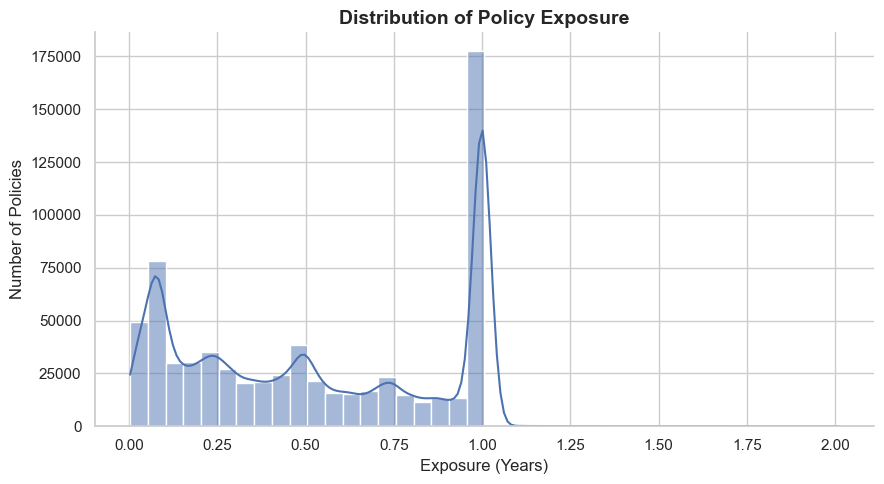

In [97]:
plt.figure(figsize = (9,5))

sns.histplot(
    data = portfolio,
    x = "Exposure",
    bins = 40,
    kde = True
)

plt.title("Distribution of Policy Exposure", fontsize=14, fontweight="bold")
plt.xlabel("Exposure (Years)")
plt.ylabel("Number of Policies")
sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\01_exposure_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

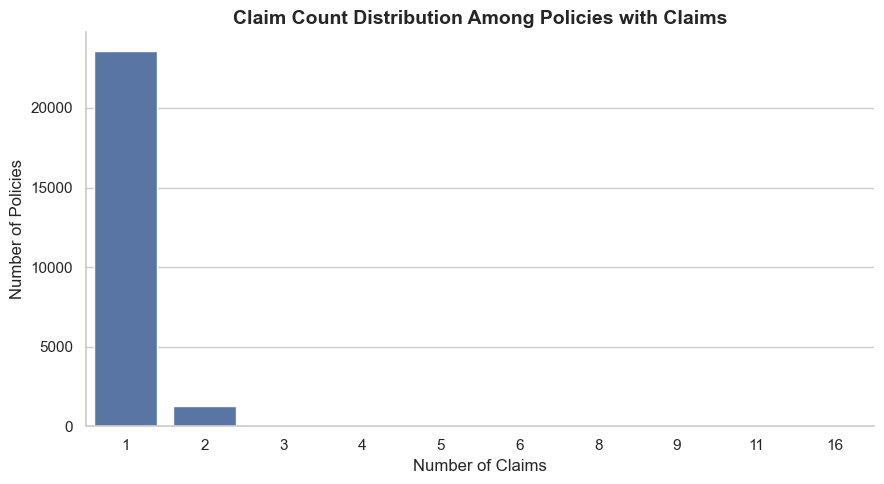

In [98]:
claim_positive = portfolio[portfolio["ClaimNb"] > 0]

plt.figure(figsize=(9, 5))

sns.countplot(
    data=claim_positive,
    x="ClaimNb"
)

plt.title(
    "Claim Count Distribution Among Policies with Claims",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Claims")
plt.ylabel("Number of Policies")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\03_positive_claim_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

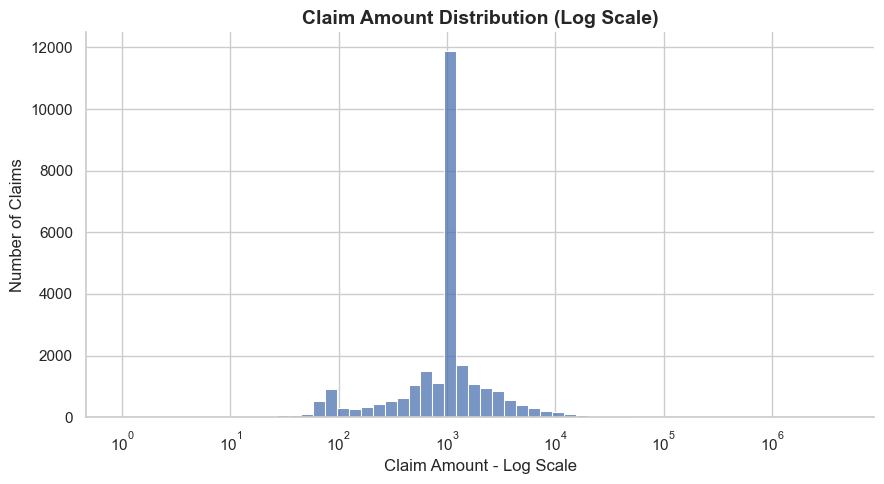

In [99]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=sev,
    x="ClaimAmount",
    bins=60,
    log_scale=True
)

plt.title(
    "Claim Amount Distribution (Log Scale)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Claim Amount - Log Scale")
plt.ylabel("Number of Claims")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\05_claim_amount_log_scale.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

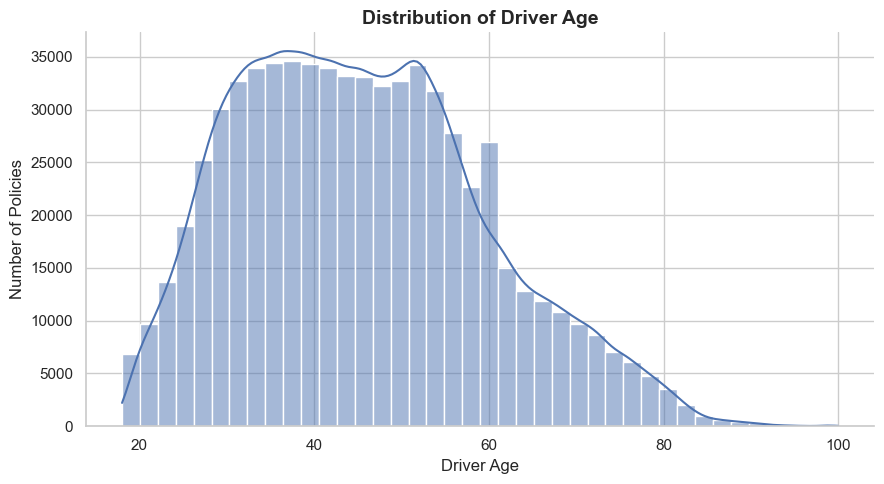

In [100]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=portfolio,
    x="DrivAge",
    bins=40,
    kde=True
)

plt.title("Distribution of Driver Age", fontsize=14, fontweight="bold")
plt.xlabel("Driver Age")
plt.ylabel("Number of Policies")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\06_driver_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

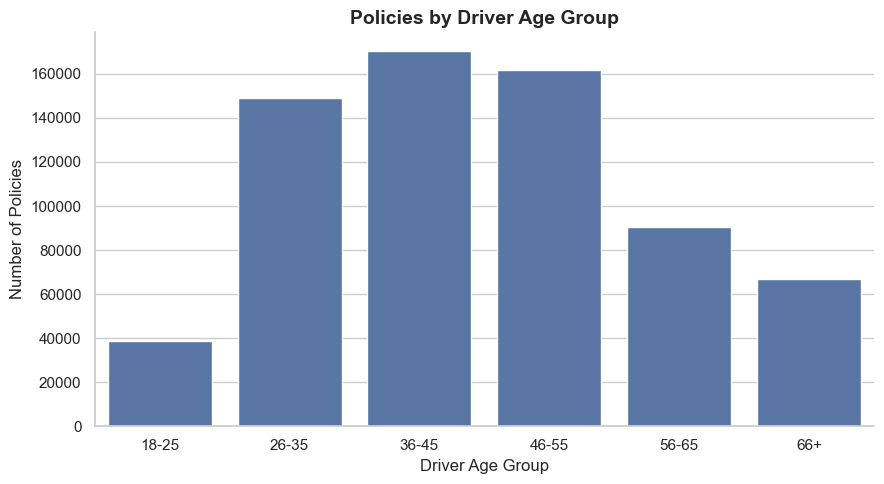

In [101]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=portfolio,
    x="DriverAgeGroup"
)

plt.title("Policies by Driver Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Driver Age Group")
plt.ylabel("Number of Policies")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\07_driver_age_groups.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

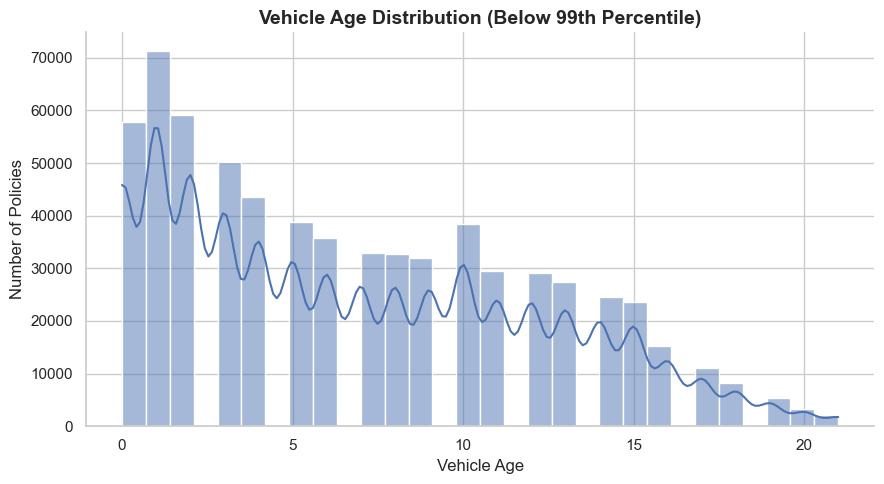

In [102]:
vehicle_99 = portfolio["VehAge"].quantile(0.99)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=portfolio[portfolio["VehAge"] <= vehicle_99],
    x="VehAge",
    bins=30,
    kde=True
)

plt.title(
    "Vehicle Age Distribution (Below 99th Percentile)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Vehicle Age")
plt.ylabel("Number of Policies")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\08_vehicle_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

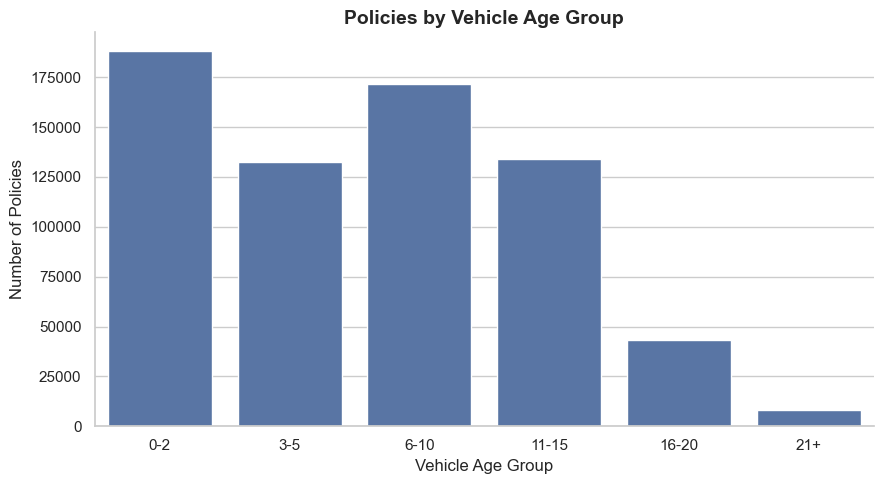

In [103]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=portfolio,
    x="Vehicle Age Groups"
)

plt.title("Policies by Vehicle Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Vehicle Age Group")
plt.ylabel("Number of Policies")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\09_vehicle_age_groups.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

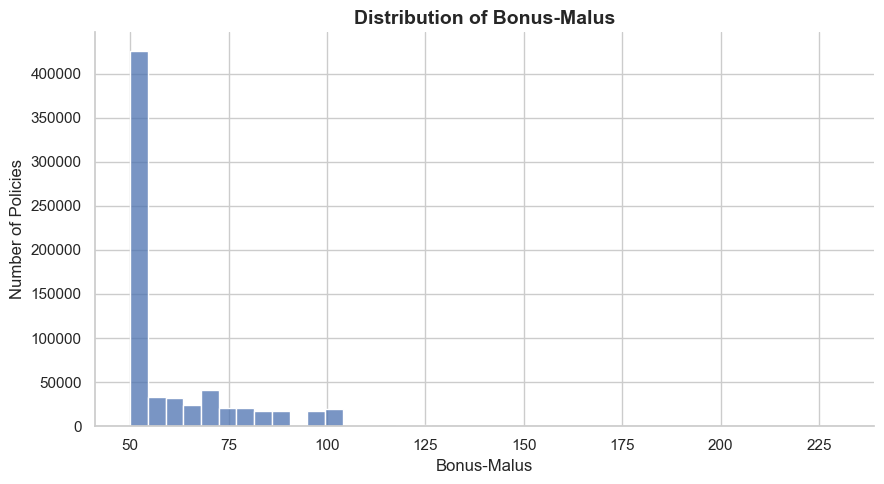

In [104]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=portfolio,
    x="BonusMalus",
    bins=40
)

plt.title("Distribution of Bonus-Malus", fontsize=14, fontweight="bold")
plt.xlabel("Bonus-Malus")
plt.ylabel("Number of Policies")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\10_bonus_malus_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

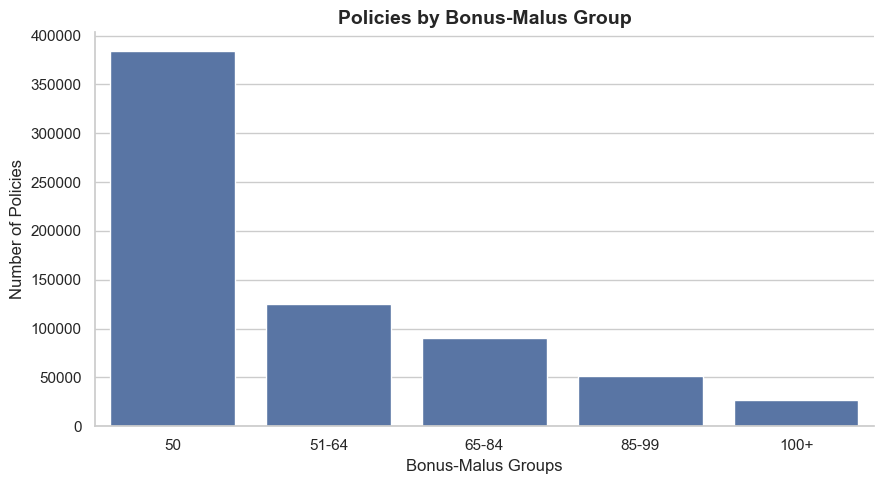

In [105]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=portfolio,
    x="Bonus-Malus Groups"
)

plt.title("Policies by Bonus-Malus Group", fontsize=14, fontweight="bold")
plt.xlabel("Bonus-Malus Groups")
plt.ylabel("Number of Policies")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\11_bonus_malus_groups.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

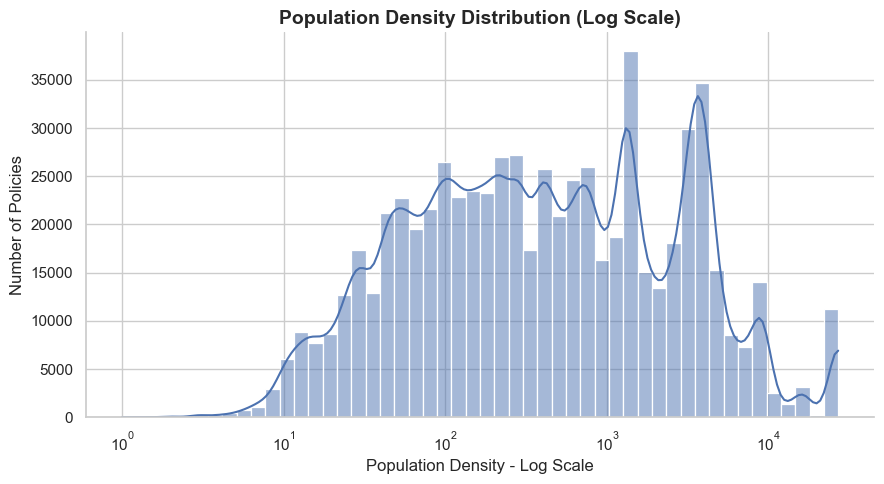

In [106]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=portfolio,
    x="Density",
    bins=50,
    log_scale=True,
    kde=True
)

plt.title(
    "Population Density Distribution (Log Scale)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Population Density - Log Scale")
plt.ylabel("Number of Policies")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\12_density_distribution_log_scale.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [107]:
### EDA Summary

#- Most policies have zero observed claims, while multiple-claim policies are relatively uncommon.
#- Exposure varies across policies, supporting the use of exposure-adjusted claim frequency.
#- Claim amounts are strongly right-skewed and contain a small number of very large claims.
#- Driver age, vehicle age, Bonus-Malus, and population density show different levels of concentration and skewness.
#- Extreme observations were retained and will be investigated further during segment analysis, Pareto analysis, and extreme-claim review.

### Why Quantiles and Log Scale Were Used

#Quantiles were used to identify the range containing the majority of observations and to better inspect highly skewed variables. For example, the 99th percentile was used to visualize the main body of the `ClaimAmount` and `VehAge` distributions without allowing a small number of extreme values to compress the rest of the chart. These observations were not removed from the dataset; they were only excluded from selected visualizations for better readability.

#Log scale was used for strongly right-skewed variables such as `ClaimAmount` and `Density`. Because these variables contain values that differ by several orders of magnitude, a logarithmic axis makes both smaller and larger observations easier to visualize on the same chart without modifying the underlying data.

In [108]:
#Region & Segment Analysis

In [109]:
region_summary = (
    portfolio.groupby("Region")
    .agg(
        policy_count = ("IDpol" , "nunique"),
        total_exposure = ("Exposure", "sum"),
        claim_count = ("ClaimNb" , "sum"),
        total_claim_cost = ("total_claim_cost" , "sum"),
        observed_claims = ("observed_claim_rows" , "sum")
    )
    .reset_index()
)

In [110]:
region_summary["claim_frequency"] = (
    region_summary["claim_count"] / region_summary["total_exposure"]
)

region_summary["average_severity"] = (
    region_summary["total_claim_cost"] / region_summary["observed_claims"]
)

In [111]:
region_summary.head()

,Region,policy_count,total_exposure,claim_count,total_claim_cost,observed_claims,claim_frequency,average_severity
0,Alsace,2200,1209.115823,92,121424.99,92.0,0.076089,1319.836848
1,Aquitaine,31329,14322.166692,1055,1916138.54,1055.0,0.073662,1816.245062
2,Auvergne,5287,2322.884229,141,183974.83,141.0,0.060700,1304.786028
3,Basse-Normandie,10892,6657.801142,452,929847.31,452.0,0.067890,2057.184314
4,Bourgogne,10491,5025.098609,345,636298.04,345.0,0.068655,1844.342145


In [112]:
region_summary.sort_values(
    "claim_frequency",
    ascending = False
).head()

,Region,policy_count,total_exposure,claim_count,total_claim_cost,observed_claims,claim_frequency,average_severity
21,Rhone-Alpes,84748,45343.547286,4233,10278303.85,4233.0,0.093354,2428.136983
18,Picardie,7994,3574.410221,314,687624.87,314.0,0.087847,2189.888121
11,Ile-de-France,69789,30207.161954,2591,4563221.86,2591.0,0.085774,1761.181729
20,Provence-Alpes-Cotes-D'Azur,79315,35790.321015,2986,6871024.80,2986.0,0.083430,2301.079973
13,Limousin,4567,2395.994542,197,280285.14,197.0,0.082221,1422.767208


In [113]:
region_summary.sort_values(
    "total_claim_cost",
    ascending=False
).head(10)

,Region,policy_count,total_exposure,claim_count,total_claim_cost,observed_claims,claim_frequency,average_severity
6,Centre,160595,102707.853386,6475,19074802.36,6475.0,0.063043,2945.915422
21,Rhone-Alpes,84748,45343.547286,4233,10278303.85,4233.0,0.093354,2428.136983
20,Provence-Alpes-Cotes-D'Azur,79315,35790.321015,2986,6871024.80,2986.0,0.083430,2301.079973
11,Ile-de-France,69789,30207.161954,2591,4563221.86,2591.0,0.085774,1761.181729
5,Bretagne,42120,27752.443675,1871,3901051.25,1871.0,0.067417,2085.008685
17,Pays-de-la-Loire,38747,21931.151165,1576,2570964.93,1576.0,0.071861,1631.322925
12,Languedoc-Roussillon,35805,14736.104177,1068,2030911.08,1068.0,0.072475,1901.602135
1,Aquitaine,31329,14322.166692,1055,1916138.54,1055.0,0.073662,1816.245062
16,Nord-Pas-de-Calais,27284,11496.974269,944,1634689.72,944.0,0.082109,1731.662839
19,Poitou-Charentes,19046,11163.408715,800,1305107.78,800.0,0.071663,1631.384725


In [114]:
region_frequency = region_summary.sort_values(
    "claim_frequency",
    ascending=False
)

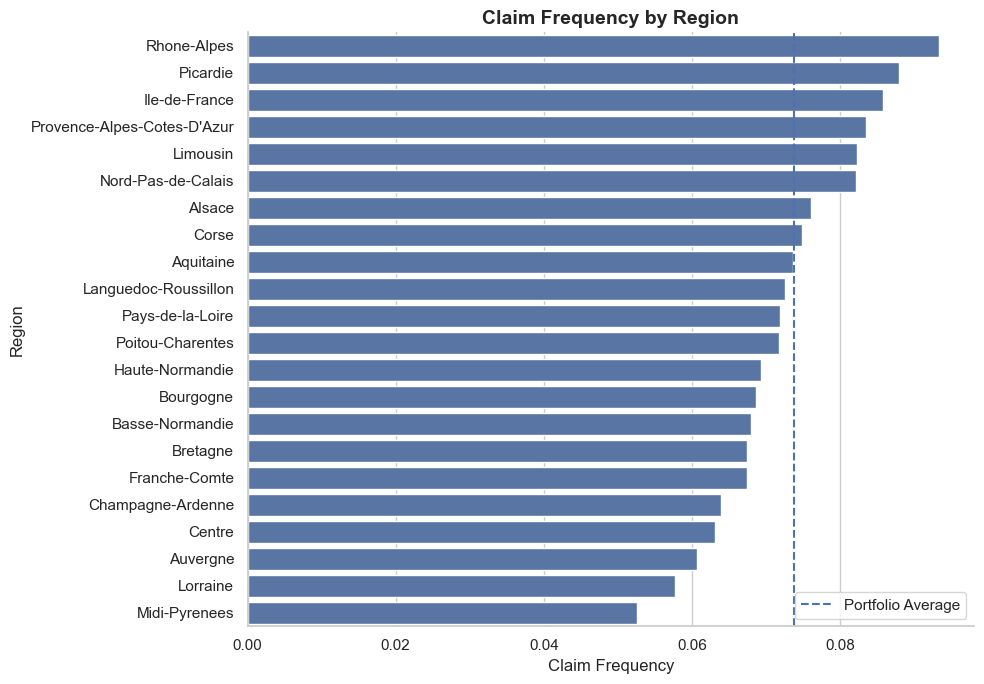

In [115]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data = region_frequency,
    x = "claim_frequency",
    y = "Region"
)

plt.title(
    "Claim Frequency by Region",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Claim Frequency")
plt.ylabel("Region")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\13_claim_frequency_by_region.png",
    dpi=300,
    bbox_inches="tight"
)
plt.axvline(
    claim_frequency,
    linestyle="--",
    label="Portfolio Average"
)

plt.legend()
plt.show()

In [116]:
region_cost = region_summary.sort_values(
    "total_claim_cost",
    ascending=False
)

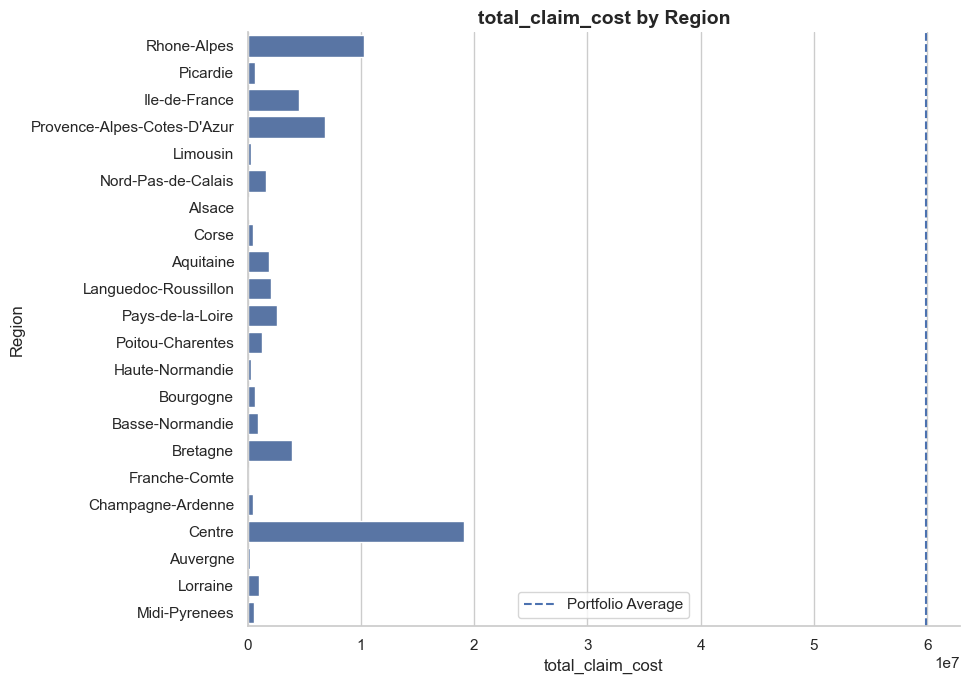

In [117]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data = region_frequency,
    x = "total_claim_cost",
    y = "Region"
)

plt.title(
    "total_claim_cost by Region",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("total_claim_cost")
plt.ylabel("Region")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\13_total_claim_cost_by_region.png",
    dpi=300,
    bbox_inches="tight"
)
plt.axvline(
    total_claim_cost,
    linestyle="--",
    label="Portfolio Average"
)

plt.legend()
plt.show()

In [118]:
region_severity = region_summary.sort_values(
    "average_severity",
    ascending=False
)

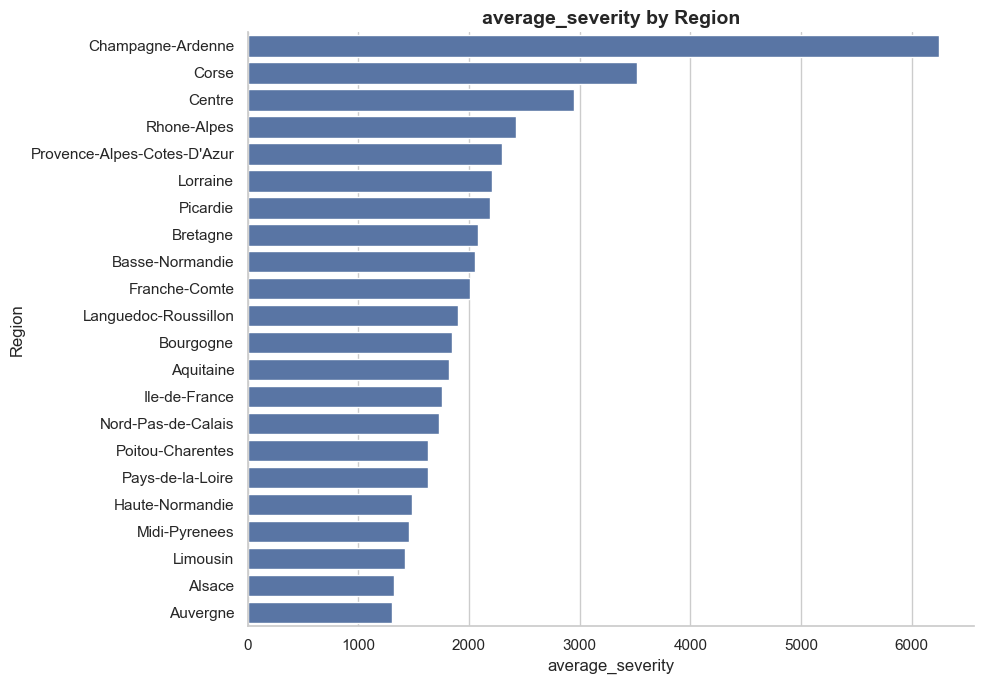

In [119]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data = region_severity,
    x = "average_severity",
    y = "Region"
)

plt.title(
    "average_severity by Region",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("average_severity")
plt.ylabel("Region")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\13_average_severity_by_region.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [120]:
### Q2 Regional Analysis – Key Finding

#Regional claim burden differs depending on the KPI considered. Centre has the highest total claim cost, but it also represents the largest portfolio exposure and has a claim frequency below the overall portfolio average.

#Rhone-Alpes deserves closer attention because it combines the highest claim frequency (9.34%) with the second-highest total claim cost (approximately 10.28M) and an average claim severity above the portfolio baseline.

#This demonstrates why regional performance should be evaluated using exposure-adjusted frequency, severity, and total cost together rather than raw claim counts alone.

In [121]:
driver_summary = (
    portfolio.groupby("DriverAgeGroup")
    .agg(
        policy_count = ("IDpol" , "nunique"),
        total_exposure = ("Exposure", "sum"),
        claim_count = ("ClaimNb" , "sum"),
        total_claim_cost = ("total_claim_cost" , "sum"),
        observed_claim = ("observed_claim_rows", "sum")
    )
    .reset_index()
)

C:\Users\asust\AppData\Local\Temp\ipykernel_6852\601349461.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  portfolio.groupby("DriverAgeGroup")


In [122]:
driver_summary["claim_frequency"] = (
    driver_summary["claim_count"] /
    driver_summary["total_exposure"]
)

driver_summary["average_severity"] = (
    driver_summary["total_claim_cost"] /
    driver_summary["observed_claim"]
)

In [123]:
driver_summary

,DriverAgeGroup,policy_count,total_exposure,claim_count,total_claim_cost,observed_claim,claim_frequency,average_severity
0,18-25,38893,16226.113263,2403,12307261.54,2403.0,0.148095,5121.623612
1,26-35,149180,69265.528075,5167,10607248.80,5167.0,0.074597,2052.883453
2,36-45,170345,87695.996287,6315,12119011.84,6315.0,0.072010,1919.083427
3,46-55,161895,89265.746408,6622,12326494.29,6622.0,0.074183,1861.445831
4,56-65,90687,51772.833261,3316,6267615.63,3316.0,0.064049,1890.113278
5,66+,66991,44256.618167,2621,6281584.40,2621.0,0.059223,2396.636551


In [124]:
vehicle_age_summary = (
    portfolio.groupby("Vehicle Age Groups", observed=True)
    .agg(
        policy_count=("IDpol", "nunique"),
        total_exposure=("Exposure", "sum"),
        claim_count=("ClaimNb", "sum"),
        total_claim_cost=("total_claim_cost", "sum"),
        observed_claims=("observed_claim_rows", "sum")
    )
    .reset_index()
)

In [125]:
vehicle_age_summary["claim_frequency"] = (
    vehicle_age_summary["claim_count"] /
    vehicle_age_summary["total_exposure"]
)
vehicle_age_summary["average_severity"] = (
    vehicle_age_summary["total_claim_cost"] /
    vehicle_age_summary["observed_claims"]
)

In [126]:
vehicle_age_summary

,Vehicle Age Groups,policy_count,total_exposure,claim_count,total_claim_cost,observed_claims,claim_frequency,average_severity
0,0-2,188140,79171.135347,5747,12299662.34,5747.0,0.072590,2140.188331
1,3-5,132488,72038.123776,5344,10552899.23,5344.0,0.074183,1974.719167
2,6-10,171587,99003.236360,8009,15805071.87,8009.0,0.080896,1973.413893
3,11-15,134059,77987.995407,5680,17808346.08,5680.0,0.072832,3135.272197
4,16-20,43396,25135.228607,1457,3010392.67,1457.0,0.057966,2066.158318
5,21+,8321,5147.115965,207,432844.31,207.0,0.040217,2091.035314


In [127]:
bonus_summary = (
    portfolio.groupby("Bonus-Malus Groups", observed=True)
    .agg(
        policy_count=("IDpol", "nunique"),
        total_exposure=("Exposure", "sum"),
        claim_count=("ClaimNb", "sum"),
        total_claim_cost=("total_claim_cost", "sum"),
        observed_claims=("observed_claim_rows", "sum")
    )
    .reset_index()
)

In [128]:
bonus_summary["claim_frequency"] = (
    bonus_summary["claim_count"] /
    bonus_summary["total_exposure"]
)
bonus_summary["average_severity"] = (
    bonus_summary["total_claim_cost"] /
    bonus_summary["observed_claims"]
)

In [129]:
bonus_summary

,Bonus-Malus Groups,policy_count,total_exposure,claim_count,total_claim_cost,observed_claims,claim_frequency,average_severity
0,50,384142,225222.490902,11592,22282394.02,11592.0,0.051469,1922.221706
1,51-64,124708,62459.171755,5516,11153629.66,5516.0,0.088314,2022.050337
2,65-84,89872,39206.419519,4110,8304366.17,4110.0,0.104830,2020.527049
3,85-99,51945,21782.560927,2650,5421848.51,2650.0,0.121657,2045.980570
4,100+,27324,9812.192359,2576,12746978.14,2576.0,0.262531,4948.361079


In [130]:
fuel_summary = (
    portfolio.groupby("VehGas", observed=True)
    .agg(
        policy_count=("IDpol", "nunique"),
        total_exposure=("Exposure", "sum"),
        claim_count=("ClaimNb", "sum"),
        total_claim_cost=("total_claim_cost", "sum"),
        observed_claims=("observed_claim_rows", "sum")
    )
    .reset_index()
)

In [131]:
fuel_summary["claim_frequency"] = (
    fuel_summary["claim_count"] /
    fuel_summary["total_exposure"]
)
fuel_summary["average_severity"] = (
    fuel_summary["total_claim_cost"] /
    fuel_summary["observed_claims"]
)

In [132]:
fuel_summary

,VehGas,policy_count,total_exposure,claim_count,total_claim_cost,observed_claims,claim_frequency,average_severity
0,Diesel,332128,170653.973126,13450,27594673.95,13450.0,0.078814,2051.648621
1,Regular,345863,187828.862336,12994,32314542.55,12994.0,0.069180,2486.881834


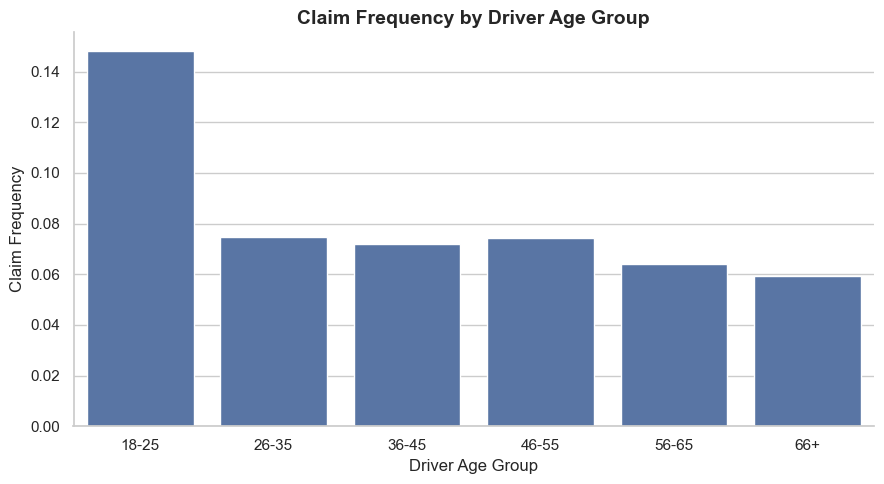

In [133]:
plt.figure(figsize = (9,5))

sns.barplot(
    data = driver_summary,
    x = "DriverAgeGroup",
    y = "claim_frequency"
)

plt.title("Claim Frequency by Driver Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Driver Age Group")
plt.ylabel("Claim Frequency")
sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\13_driver_age_claim_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

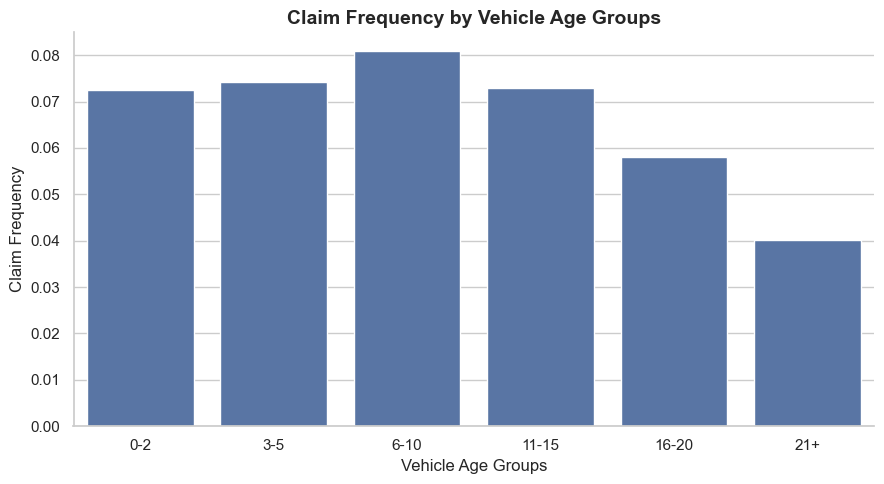

In [134]:
plt.figure(figsize = (9,5))

sns.barplot(
    data = vehicle_age_summary,
    x = "Vehicle Age Groups",
    y = "claim_frequency"
)

plt.title("Claim Frequency by Vehicle Age Groups", fontsize=14, fontweight="bold")
plt.xlabel("Vehicle Age Groups")
plt.ylabel("Claim Frequency")
sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\13_vehicle_age_claim_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

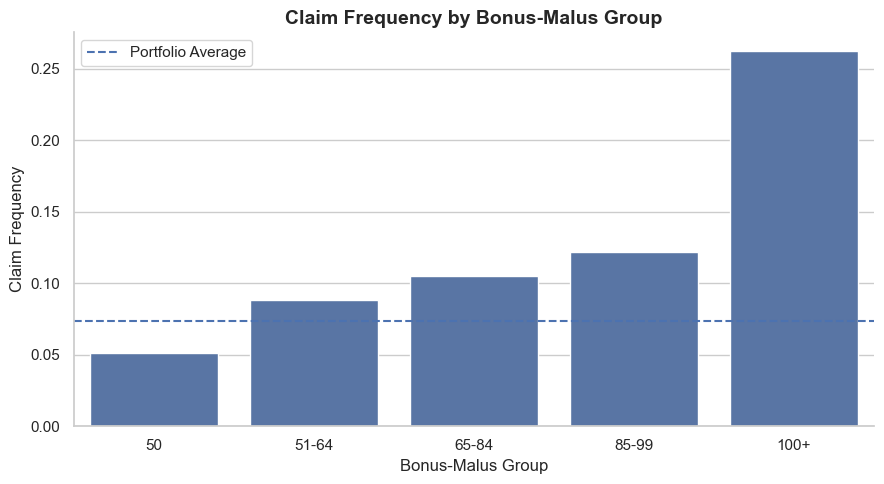

In [135]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=bonus_summary,
    x="Bonus-Malus Groups",
    y="claim_frequency"
)

plt.axhline(
    claim_frequency,
    linestyle="--",
    label="Portfolio Average"
)

plt.title(
    "Claim Frequency by Bonus-Malus Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Bonus-Malus Group")
plt.ylabel("Claim Frequency")

plt.legend()
sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\16_bonus_malus_claim_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

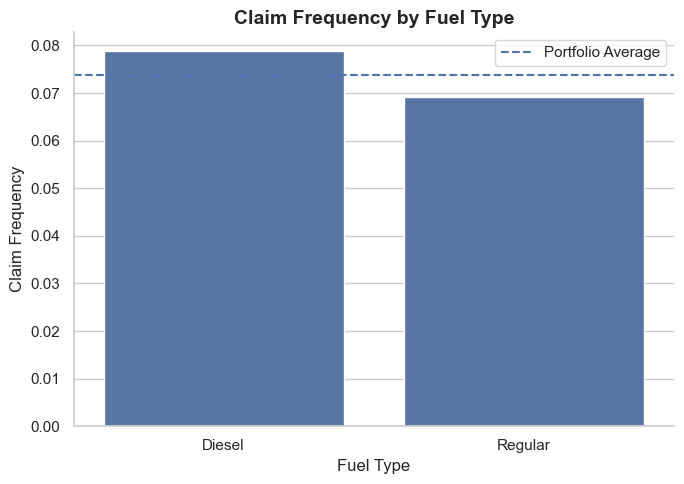

In [136]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=fuel_summary,
    x="VehGas",
    y="claim_frequency"
)

plt.axhline(
    claim_frequency,
    linestyle="--",
    label="Portfolio Average"
)

plt.title(
    "Claim Frequency by Fuel Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fuel Type")
plt.ylabel("Claim Frequency")

plt.legend()
sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\17_fuel_type_claim_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [137]:
### Q3 – Which Driver and Vehicle Segments Show Different Claim Patterns?

#The segment analysis shows clear differences in both claim frequency and claim severity across driver and vehicle characteristics.

#- Drivers aged **18–25** have the highest claim frequency and substantially higher average claim severity than the overall portfolio.
#- Vehicles aged **6–10 years** show the highest claim frequency, while vehicles aged **11–15 years** have the highest average claim severity.
#- Claim frequency increases across higher **Bonus-Malus** groups, with the **100+** group showing the highest frequency and severity.
#- Diesel policies have higher claim frequency, while Regular-fuel policies show higher average claim severity.

#These results indicate meaningful differences between segments, but they represent descriptive associations and should not be interpreted as causal effects.

In [138]:
# Q4 — Frequency vs Severity

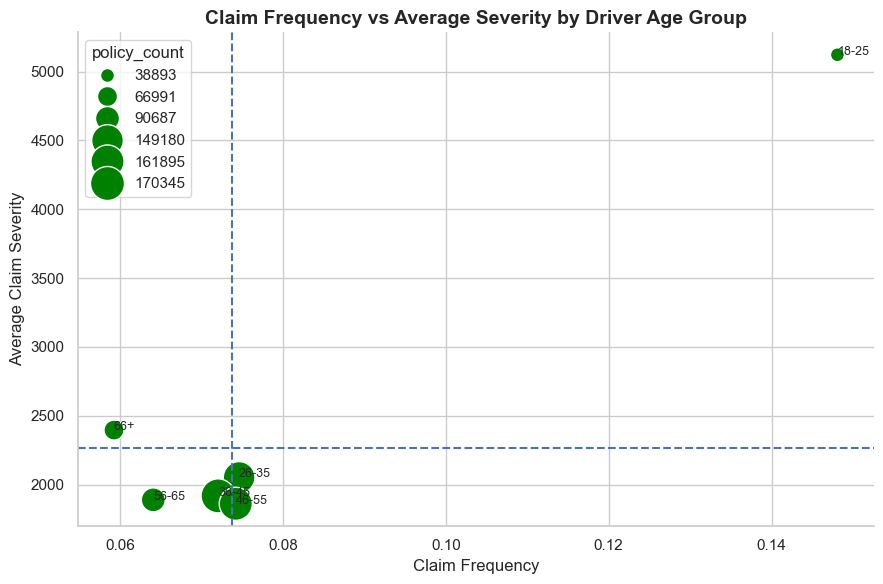

In [139]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=driver_summary,
    x="claim_frequency",
    y="average_severity",
    size="policy_count",
    sizes=(100, 600),
    color = "green"
)

plt.axvline(
    claim_frequency,
    linestyle="--"
)

plt.axhline(
    average_claim_severity,
    linestyle="--"
)

for _, row in driver_summary.iterrows():
    plt.text(
        row["claim_frequency"],
        row["average_severity"],
        str(row["DriverAgeGroup"]),
        fontsize=9
    )

plt.title(
    "Claim Frequency vs Average Severity by Driver Age Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Claim Frequency")
plt.ylabel("Average Claim Severity")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\18_driver_frequency_vs_severity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

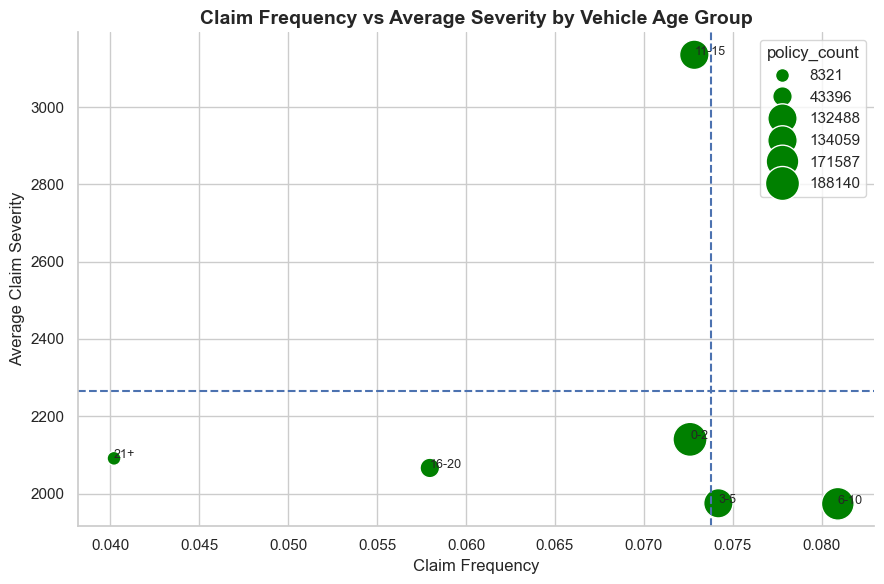

In [140]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=vehicle_age_summary,
    x="claim_frequency",
    y="average_severity",
    size="policy_count",
    sizes=(100, 600),
    color = "green"
)

plt.axvline(
    claim_frequency,
    linestyle="--"
)

plt.axhline(
    average_claim_severity,
    linestyle="--"
)

for _, row in vehicle_age_summary.iterrows():
    plt.text(
        row["claim_frequency"],
        row["average_severity"],
        str(row["Vehicle Age Groups"]),
        fontsize=9
    )

plt.title(
    "Claim Frequency vs Average Severity by Vehicle Age Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Claim Frequency")
plt.ylabel("Average Claim Severity")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\18_vehicle_frequency_vs_severity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

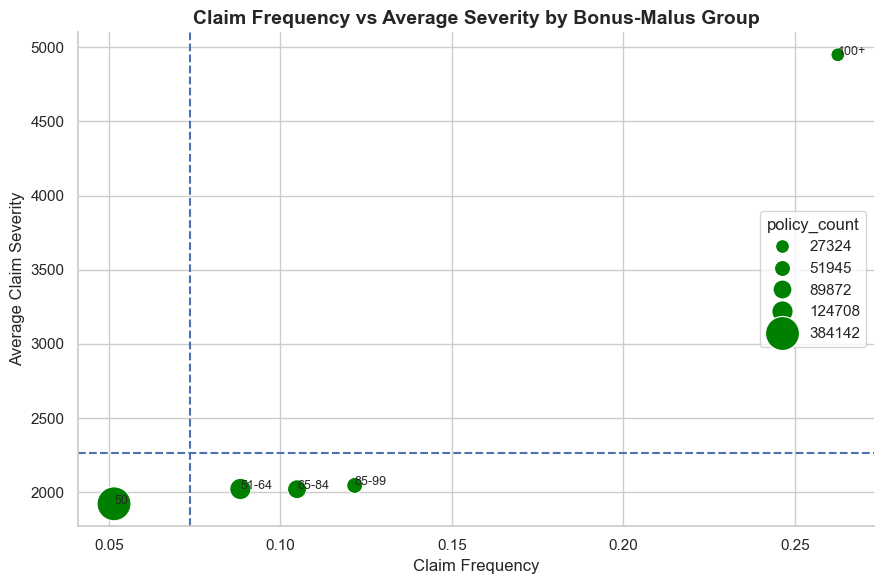

In [141]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=bonus_summary,
    x="claim_frequency",
    y="average_severity",
    size="policy_count",
    sizes=(100, 600),
    color = "green"
)

plt.axvline(
    claim_frequency,
    linestyle="--"
)

plt.axhline(
    average_claim_severity,
    linestyle="--"
)

for _, row in bonus_summary.iterrows():
    plt.text(
        row["claim_frequency"],
        row["average_severity"],
        str(row["Bonus-Malus Groups"]),
        fontsize=9
    )

plt.title(
    "Claim Frequency vs Average Severity by Bonus-Malus Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Claim Frequency")
plt.ylabel("Average Claim Severity")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\18_Bonus-Malus_frequency_vs_severity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [142]:
### Q4 – Are Frequent-Claim Segments Also Expensive-Claim Segments?

# The frequency-versus-severity analysis shows that higher claim frequency does not always correspond to higher average claim severity.

# The 18–25 driver group stands out with both substantially higher claim frequency and severity, while some other segments show high severity despite relatively low claim frequency.

# Vehicle-age segments also demonstrate different patterns: vehicles aged 6–10 have the highest claim frequency, whereas vehicles aged 11–15 have the highest average severity.

# The Bonus-Malus 100+ segment shows both exceptionally high claim frequency and high average severity.

# These results confirm the importance of evaluating claim frequency and severity separately rather than relying on a single claim-risk measure.

In [143]:
# pareto analysis

In [144]:
pareto_claims = sev.sort_values(
    "ClaimAmount",
    ascending=False
).copy()


In [145]:
pareto_claims.head(10)

,IDpol,ClaimAmount
9756,1120377,4075400.56
15768,110846,1403057.40
11637,2141337,1301172.60
17992,3122016,774411.50
2869,2008127,390742.27
3307,3025890,369131.88
9999,1117644,307096.42
5521,158309,301635.49
18627,3075820,287423.00
18295,3150210,281897.49


In [146]:
total_cost = pareto_claims["ClaimAmount"].sum()


In [147]:
pareto_claims["cumulative_cost"] = (
    pareto_claims["ClaimAmount"].cumsum()
)


In [148]:
pareto_claims["cumulative_cost_share"] = (
    pareto_claims["cumulative_cost"] / total_cost
)


In [149]:
pareto_claims.head(10)

,IDpol,ClaimAmount,cumulative_cost,cumulative_cost_share
9756,1120377,4075400.56,4075400.56,0.068026
15768,110846,1403057.40,5478457.96,0.091446
11637,2141337,1301172.60,6779630.56,0.113165
17992,3122016,774411.50,7554042.06,0.126091
2869,2008127,390742.27,7944784.33,0.132614
3307,3025890,369131.88,8313916.21,0.138775
9999,1117644,307096.42,8621012.63,0.143901
5521,158309,301635.49,8922648.12,0.148936
18627,3075820,287423.00,9210071.12,0.153734
18295,3150210,281897.49,9491968.61,0.158439


In [150]:
pareto_claims["claim_rank"] = range(
    1,
    len(pareto_claims) + 1
)

In [151]:
pareto_claims["cumulative_claim_share"] = (
    pareto_claims["claim_rank"] /
    len(pareto_claims)
)

In [152]:
pareto_claims[
    [
        "ClaimAmount",
        "cumulative_claim_share",
        "cumulative_cost_share"
    ]
].head(10)

,ClaimAmount,cumulative_claim_share,cumulative_cost_share
9756,4075400.56,0.000038,0.068026
15768,1403057.40,0.000076,0.091446
11637,1301172.60,0.000113,0.113165
17992,774411.50,0.000151,0.126091
2869,390742.27,0.000189,0.132614
3307,369131.88,0.000227,0.138775
9999,307096.42,0.000265,0.143901
5521,301635.49,0.000303,0.148936
18627,287423.00,0.000340,0.153734
18295,281897.49,0.000378,0.158439


In [153]:
top_1_n = int(len(pareto_claims) * 0.01)

top_1_n

264

In [154]:
top_1_cost = (
    pareto_claims.head(top_1_n)["ClaimAmount"].sum()
)

In [155]:
top_1_share = top_1_cost / total_cost

In [156]:
print(f"Top 1% of claims account for {top_1_share:.2%} of total claim cost.")

Top 1% of claims account for 37.99% of total claim cost.


In [157]:
top_5_n = int(len(pareto_claims) * 0.05)

top_5_cost = (
    pareto_claims.head(top_5_n)["ClaimAmount"].sum()
)

top_5_share = top_5_cost / total_cost

print(f"Top 5% of claims account for {top_5_share:.2%} of total claim cost.")

Top 5% of claims account for 52.09% of total claim cost.


In [158]:
top_10_n = int(len(pareto_claims) * 0.10)

top_10_cost = (
    pareto_claims.head(top_10_n)["ClaimAmount"].sum()
)

top_10_share = top_10_cost / total_cost

print(f"Top 10% of claims account for {top_10_share:.2%} of total claim cost.")

Top 10% of claims account for 59.92% of total claim cost.


In [159]:
print(f"Top 1% of claims: {top_1_share:.2%}")
print(f"Top 5% of claims: {top_5_share:.2%}")
print(f"Top 10% of claims: {top_10_share:.2%}")

Top 1% of claims: 37.99%
Top 5% of claims: 52.09%
Top 10% of claims: 59.92%


In [160]:
claims_for_80 = pareto_claims[
    pareto_claims["cumulative_cost_share"] >= 0.80
].iloc[0]

In [161]:
share_for_80 = claims_for_80["cumulative_claim_share"]

print(
    f"{share_for_80:.2%} of the highest-cost claims account for 80% of total claim cost."
)

40.62% of the highest-cost claims account for 80% of total claim cost.


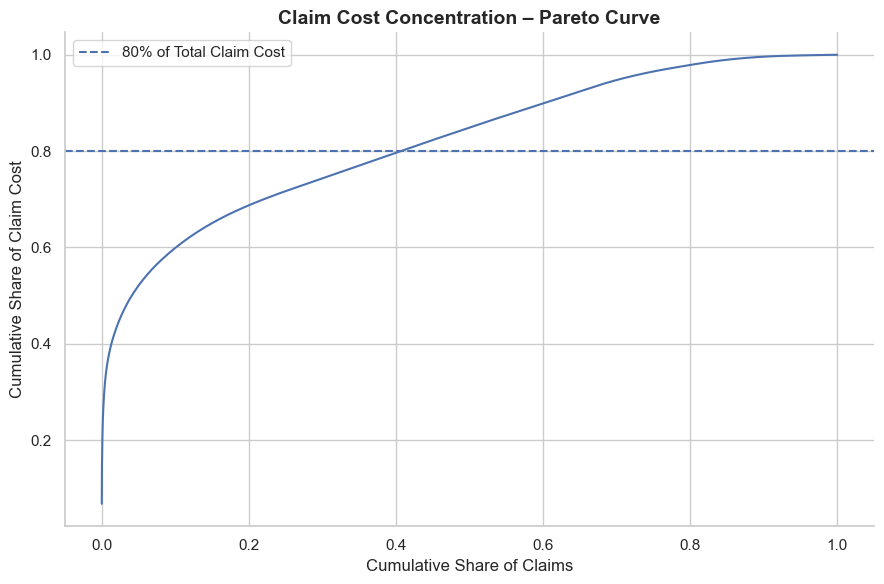

In [162]:
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=pareto_claims,
    x="cumulative_claim_share",
    y="cumulative_cost_share"
)

plt.axhline(
    0.80,
    linestyle="--",
    label="80% of Total Claim Cost"
)

plt.xlabel("Cumulative Share of Claims")
plt.ylabel("Cumulative Share of Claim Cost")

plt.title(
    "Claim Cost Concentration – Pareto Curve",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\21_claim_cost_pareto.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [163]:
### Q5 – Is Claim Cost Concentrated in a Small Number of Claims?

# Claim costs show a noticeable level of concentration among high-cost claims.

#- The top 1% of claims account for approximately **37.99%** of total claim cost.
#- The top 5% account for approximately **52.09%**.
#- The top 10% account for approximately **59.92%**.
#- Approximately **40.62%** of the highest-cost claims are required to reach 80% of total claim cost.

#These results indicate that high-cost claims contribute disproportionately to the overall claim burden, although the distribution does not follow a strict 80/20 pattern.

In [189]:
# Q6 What Unusual Claims or Segments Should Management Investigate?

In [165]:
extreme_threshold = sev["ClaimAmount"].quantile(0.999)

extreme_threshold

np.float64(152223.24082000108)

In [166]:
extreme_claims = (
    sev[sev["ClaimAmount"] >= extreme_threshold]
    .sort_values("ClaimAmount", ascending=False)
)

extreme_claims

,IDpol,ClaimAmount
9756,1120377,4075400.56
15768,110846,1403057.40
11637,2141337,1301172.60
17992,3122016,774411.50
2869,2008127,390742.27
3307,3025890,369131.88
9999,1117644,307096.42
5521,158309,301635.49
18627,3075820,287423.00
18295,3150210,281897.49


In [167]:
len(extreme_claims)

27

In [168]:
extreme_cost_share = (
    extreme_claims["ClaimAmount"].sum()
    / sev["ClaimAmount"].sum()
)

print(f"Extreme claims account for {extreme_cost_share:.2%} of total claim cost.")

Extreme claims account for 21.63% of total claim cost.


In [173]:
claim_details = sev.merge(
    portfolio[
        [
            "IDpol",
            "Region",
            "DriverAgeGroup",
            "Vehicle Age Groups",
            "Bonus-Malus Groups",
            "VehGas",
            "ClaimNb",
            "Exposure"
        ]
    ],
    on="IDpol",
    how="left",
    validate="many_to_one"
)

In [174]:
extreme_claim_details = (
    claim_details[
        claim_details["ClaimAmount"] >= extreme_threshold
    ]
    .sort_values("ClaimAmount", ascending=False)
)

In [175]:
extreme_claim_details.head(20)

,IDpol,ClaimAmount,Region,DriverAgeGroup,Vehicle Age Groups,Bonus-Malus Groups,VehGas,ClaimNb,Exposure
9756,1120377,4075400.56,Centre,18-25,11-15,100+,Regular,1,0.22
15768,110846,1403057.40,Centre,18-25,11-15,100+,Regular,2,0.43
11637,2141337,1301172.60,Rhone-Alpes,18-25,11-15,100+,Regular,1,0.32
17992,3122016,774411.50,Rhone-Alpes,36-45,6-10,51-64,Diesel,1,0.91
2869,2008127,390742.27,Rhone-Alpes,56-65,0-2,50,Regular,3,0.36
3307,3025890,369131.88,Champagne-Ardenne,36-45,0-2,50,Diesel,2,0.09
9999,1117644,307096.42,Bretagne,18-25,0-2,85-99,Diesel,1,0.85
5521,158309,301635.49,Centre,46-55,3-5,50,Diesel,1,0.75
18627,3075820,287423.00,Provence-Alpes-Cotes-D'Azur,66+,16-20,50,Regular,1,0.58
18295,3150210,281897.49,Centre,56-65,3-5,51-64,Diesel,1,0.48


In [176]:
extreme_claim_details["Region"].value_counts().head(10)

Region
Centre                         11
Rhone-Alpes                     6
Provence-Alpes-Cotes-D'Azur     3
Bretagne                        2
Champagne-Ardenne               1
Lorraine                        1
Picardie                        1
Corse                           1
Ile-de-France                   1
Name: count, dtype: int64

In [177]:
extreme_claim_details["DriverAgeGroup"].value_counts()

DriverAgeGroup
18-25    7
26-35    7
66+      6
36-45    3
56-65    3
46-55    1
Name: count, dtype: int64

In [181]:
extreme_claim_details["Bonus-Malus Groups"].value_counts()

Bonus-Malus Groups
50       9
100+     6
51-64    5
65-84    5
85-99    2
Name: count, dtype: int64

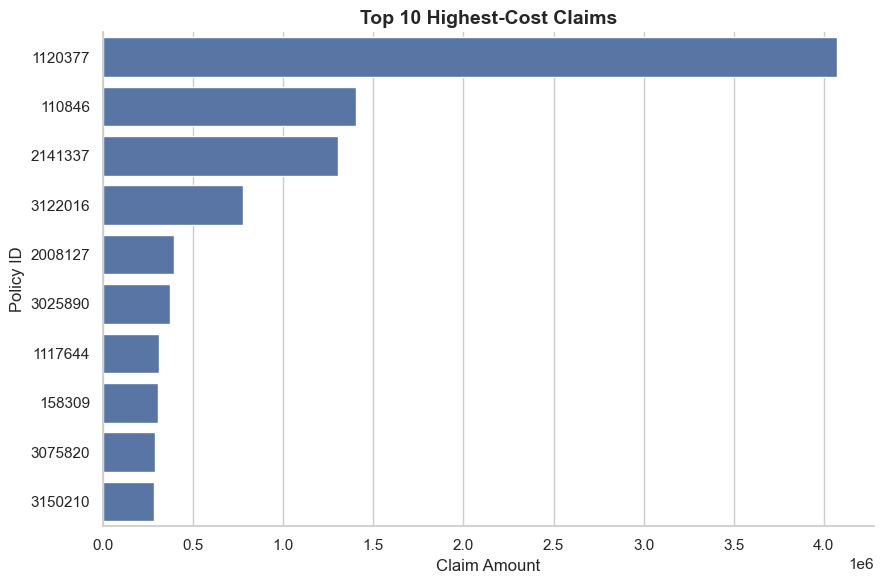

In [183]:
top_10_claims = sev.nlargest(10, "ClaimAmount")

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_10_claims,
    x="ClaimAmount",
    y=top_10_claims["IDpol"].astype(str)
    
)

plt.title(
    "Top 10 Highest-Cost Claims",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Claim Amount")
plt.ylabel("Policy ID")

sns.despine()
plt.tight_layout()

plt.savefig(
    r"D:\projects\studybuild-project 3-insurance\plots\22_top_10_highest_cost_claims.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [186]:
print("Driver Age Groups:")
print(extreme_claim_details["DriverAgeGroup"].value_counts())

print("\nVehicle Age Groups:")
print(extreme_claim_details["Vehicle Age Groups"].value_counts())

print("\nBonus-Malus Groups:")
print(extreme_claim_details["Bonus-Malus Groups"].value_counts())

print("\nRegions:")
print(extreme_claim_details["Region"].value_counts())

Driver Age Groups:
DriverAgeGroup
18-25    7
26-35    7
66+      6
36-45    3
56-65    3
46-55    1
Name: count, dtype: int64

Vehicle Age Groups:
Vehicle Age Groups
11-15    10
0-2       6
6-10      5
3-5       3
16-20     2
21+       1
Name: count, dtype: int64

Bonus-Malus Groups:
Bonus-Malus Groups
50       9
100+     6
51-64    5
65-84    5
85-99    2
Name: count, dtype: int64

Regions:
Region
Centre                         11
Rhone-Alpes                     6
Provence-Alpes-Cotes-D'Azur     3
Bretagne                        2
Champagne-Ardenne               1
Lorraine                        1
Picardie                        1
Corse                           1
Ile-de-France                   1
Name: count, dtype: int64


In [187]:
extreme_driver_rate = (
    extreme_claim_details["DriverAgeGroup"].value_counts()
    / driver_summary.set_index("DriverAgeGroup")["observed_claim"]
) * 100

extreme_driver_rate.sort_values(ascending=False)

DriverAgeGroup
18-25    0.291303
66+      0.228920
26-35    0.135475
56-65    0.090470
36-45    0.047506
46-55    0.015101
dtype: float64

In [188]:
extreme_bonus_rate = (
    extreme_claim_details["Bonus-Malus Groups"].value_counts()
    / bonus_summary.set_index("Bonus-Malus Groups")["observed_claims"]
) * 100

extreme_bonus_rate.sort_values(ascending=False)

Bonus-Malus Groups
100+     0.232919
65-84    0.121655
51-64    0.090645
50       0.077640
85-99    0.075472
dtype: float64

In [190]:
### Q6 – What Unusual Claims or Segments Should Management Investigate?

#Using the 99.9th percentile of `ClaimAmount` as the extreme-claim threshold, 27 claims above approximately 152,223 were identified.

#Although these claims represent only about 0.1% of all observed claims, they account for approximately **21.63% of total claim cost**, demonstrating the substantial financial impact of a very small number of large claims.

#After adjusting for segment claim volume, the **18–25 driver group** shows the highest extreme-claim rate (approximately 0.29%), followed by the **66+ group** (approximately 0.23%).

#The **Bonus-Malus 100+** segment also stands out, with the highest extreme-claim rate among Bonus-Malus groups (approximately 0.23%). This segment had already shown substantially elevated overall claim frequency and average severity.

#These patterns identify areas for further claims-management review. However, extreme claims should not be interpreted as evidence of fraud or causal relationships.

In [192]:
### Q7 – What Should Management Monitor Every Month?

#An executive insurance dashboard should monitor both claim occurrence and claim cost rather than relying on raw claim counts alone.

#The six core portfolio KPIs are:

#- Policy Count
#- Total Exposure
#- Claim Count
#- Claim Frequency
#- Total Claim Cost
#- Average Claim Severity

#Claim Frequency should be monitored together with Exposure because differences in portfolio size and time at risk can make raw claim counts misleading.

#Management should also monitor:

#- Regional claim frequency and claim cost
#- Driver, vehicle and Bonus-Malus segment performance
#- Frequency-versus-severity positioning of key segments
#- Large and extreme claims
#- Claim cost concentration through Pareto analysis

#Particular attention should be given to segments such as drivers aged 18–25 and Bonus-Malus 100+, which showed elevated claim frequency, severity and/or extreme-claim occurrence in the analysis.

#Useful dashboard filters include Region, Driver Age Group, Vehicle Age Group, Bonus-Malus Group and Fuel Type.

#The current dataset does not contain a date or month variable, so true month-over-month trends cannot be calculated. The dashboard should therefore be interpreted as a reporting-cycle monitoring framework that could be refreshed with new data in an operational setting.

In [194]:
### Q8 – Three Data-Driven Recommendations

#### Recommendation 1 – Prioritize Rhone-Alpes for Closer Monitoring

#**Evidence:**  
#Rhone-Alpes has the highest regional claim frequency at approximately 9.34%, with total claim cost of about 10.28M and average claim severity above the portfolio baseline.

#**Action:**  
#Prioritize Rhone-Alpes for closer monitoring in future reporting cycles and compare its performance with other regions using exposure-adjusted metrics.

#**KPI:**  
#Claim Frequency, Total Claim Cost, and Average Claim Severity.

#---

#### Recommendation 2 – Monitor the Bonus-Malus 100+ Segment Closely

#**Evidence:**  
#The Bonus-Malus 100+ segment has a claim frequency of approximately 26.25%, average claim severity of about 4,948, and the highest extreme-claim rate among Bonus-Malus groups at approximately 0.23%.

#**Action:**  
#Include this segment in a dedicated management watchlist and review its large claims and claim patterns in future reporting cycles.

#**KPI:**  
#Claim Frequency, Average Claim Severity, and Extreme Claim Rate.

#---

#### Recommendation 3 – Strengthen Large-Claim Monitoring

#**Evidence:**  
#The top 1% of claims account for approximately 37.99% of total claim cost. In addition, 27 claims above the 99.9th percentile threshold account for approximately 21.63% of total claim cost.

#**Action:**  
#Create a dedicated large-claim monitoring view to identify, review, and track high-cost claims separately from the broader portfolio.

#**KPI:**  
#Top 1% Claim Cost Share, Extreme Claim Count, and Extreme Claim Cost Share.

#These recommendations are intended to support monitoring and further investigation. They should not be interpreted as evidence of causal relationships or fraud.

In [195]:
## Analysis Limitations

#- The dataset represents historical French motor insurance policies, mainly from 2011–2013, and the insurer is anonymous.
#- Premium information is not available; therefore, Loss Ratio cannot be calculated.
#- The analysis is descriptive. Differences between driver, vehicle, regional, or Bonus-Malus segments should not be interpreted as causal effects.
#- The available variables do not capture every factor that may influence insurance claim behavior.
#- Small segments may produce unstable frequency or severity estimates and should always be interpreted together with exposure and claim counts.
#- Large claims have a substantial influence on total claim cost and average severity. These claims were retained and investigated rather than automatically removed as outliers.
#- The dataset does not include a date or month field, so month-over-month claim trends cannot be evaluated.

In [196]:
portfolio.to_csv(
    r"D:\projects\studybuild-project 3-insurance\cleaned csv\tableau_portfolio.csv",
    index=False
)

In [197]:
claim_details_tableau = pareto_claims.merge(
    portfolio[
        [
            "IDpol",
            "Region",
            "DriverAgeGroup",
            "Vehicle Age Groups",
            "Bonus-Malus Groups",
            "VehGas",
            "DrivAge",
            "VehAge",
            "BonusMalus",
            "Exposure"
        ]
    ],
    on="IDpol",
    how="left",
    validate="many_to_one"
)

In [198]:
claim_details_tableau["ExtremeClaim"] = (
    claim_details_tableau["ClaimAmount"] >= extreme_threshold
)

In [200]:
claim_details_tableau.to_csv(
    r"D:\projects\studybuild-project 3-insurance\cleaned csv\tableau_claims.csv",
    index=False
)

In [201]:
print("Portfolio rows:", len(portfolio))
print("Unique policies:", portfolio["IDpol"].nunique())

print("Claim rows:", len(claim_details_tableau))
print("Claim cost:",
      claim_details_tableau["ClaimAmount"].sum())

print("Extreme claims:",
      claim_details_tableau["ExtremeClaim"].sum())

Portfolio rows: 677991
Unique policies: 677991
Claim rows: 26444
Claim cost: 59909216.499999985
Extreme claims: 27
